<a href="https://colab.research.google.com/github/alitorbzadeh/CodeBySematec/blob/main/SematecSettion10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.layers import BatchNormalization
from sklearn.metrics import confusion_matrix
from keras.utils import to_categorical
from keras.datasets import cifar10
import matplotlib.pyplot as plt

In [9]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [10]:
input_shape = x_train.shape[1:]
num_class = len(np.unique(y_train))

In [13]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

In [14]:
y_train = to_categorical(y_train, num_class)
y_test = to_categorical(y_test, num_class)

In [17]:
model = Sequential()

In [19]:
model.add(Conv2D(32,(2,2), input_shape=input_shape, padding ='same',activation='relu'))

In [20]:
model.add(Conv2D(64,(2,2), padding ='same', activation='relu'))

In [21]:
model.add(MaxPool2D(pool_size=(2,2)))

In [22]:
model.add(Conv2D(128,(2,2), padding ='same', activation='relu'))

In [23]:
model.add(MaxPool2D(pool_size=(2,2)))

In [24]:
model.add(Flatten())

In [25]:
model.add(Dense(32, activation='relu'))

In [26]:
model.add(Dense(num_class,activation='softmax'))

In [27]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,202 (1.18 MB)

 Trainable params: 308,202 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(x_train,y_train,batch_size=64,epochs=30,validation_data=(x_test,y_test))

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4407 - loss: 1.5391 - val_accuracy: 0.5473 - val_loss: 1.2560
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6189 - loss: 1.0740 - val_accuracy: 0.6322 - val_loss: 1.0405
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6813 - loss: 0.9064 - val_accuracy: 0.6769 - val_loss: 0.9180
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7211 - loss: 0.8023 - val_accuracy: 0.6935 - val_loss: 0.8805
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7487 - loss: 0.7183 - val_accuracy: 0.7099 - val_loss: 0.8376
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7737 - loss: 0.6452 - val_accuracy: 0.7222 - val_loss: 0.8097
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7966 - loss: 0.5807 - val_accuracy: 0.7230 - val_loss: 0.8238
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8171 - loss: 0.5184 - val_accuracy

In [31]:
for key, value in history.history.items():
  print(key,value)

accuracy [0.4407399892807007, 0.618939995765686, 0.6812599897384644, 0.7210800051689148, 0.7486799955368042, 0.7737200260162354, 0.7965599894523621, 0.8171399831771851, 0.8329399824142456, 0.8519799709320068, 0.8646199703216553, 0.8802800178527832, 0.8933200240135193, 0.902899980545044, 0.9123799800872803, 0.9203799962997437, 0.9282400012016296, 0.9355199933052063, 0.9402199983596802, 0.9453200101852417, 0.9439799785614014, 0.9545800089836121, 0.9513000249862671, 0.9572799801826477, 0.9559599757194519, 0.9611600041389465, 0.9629200100898743, 0.9634000062942505, 0.9623399972915649, 0.965719997882843]
loss [1.5391478538513184, 1.0740495920181274, 0.9064049124717712, 0.8022606372833252, 0.7183094024658203, 0.645158052444458, 0.5807458758354187, 0.518399178981781, 0.4678989052772522, 0.4167135953903198, 0.3812405467033386, 0.3339866101741791, 0.3006572723388672, 0.26929202675819397, 0.24247977137565613, 0.21897709369659424, 0.19761641323566437, 0.1812915802001953, 0.1634364277124405, 0.150

<Axes: >

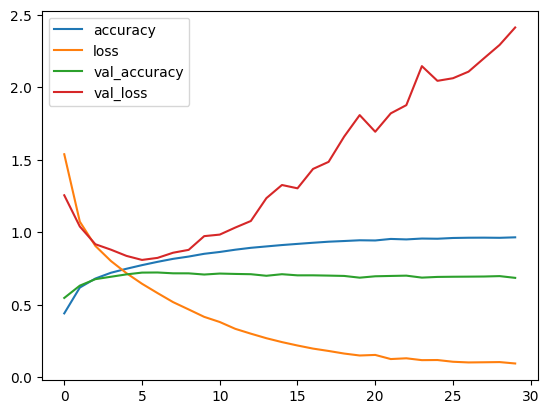

In [34]:
pd.DataFrame(history.history).plot()


<Axes: >

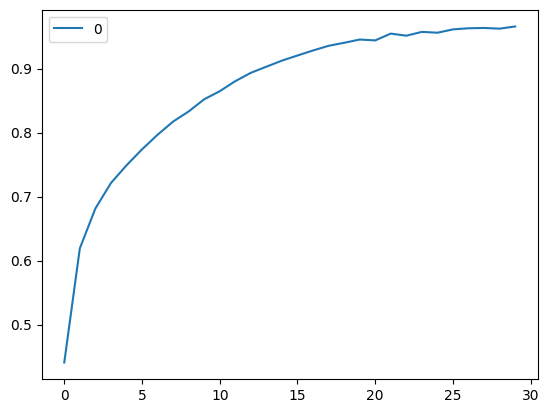

In [35]:
pd.DataFrame(history.history['accuracy']).plot()

<Axes: >

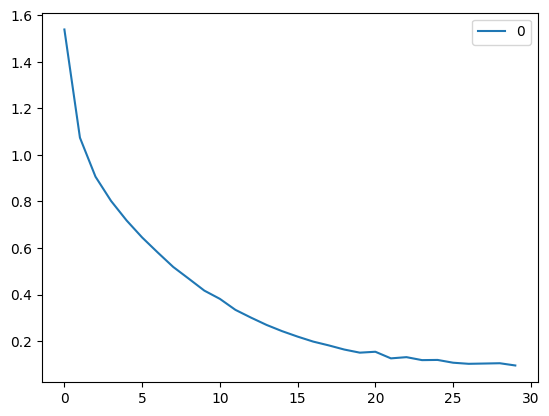

In [36]:
pd.DataFrame(history.history['loss']).plot()

<Axes: >

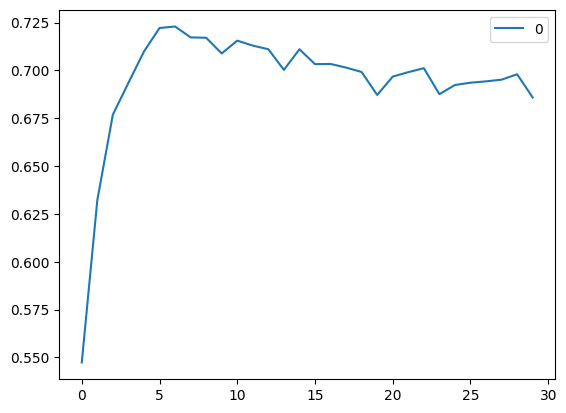

In [37]:
pd.DataFrame(history.history['val_accuracy']).plot()

<Axes: >

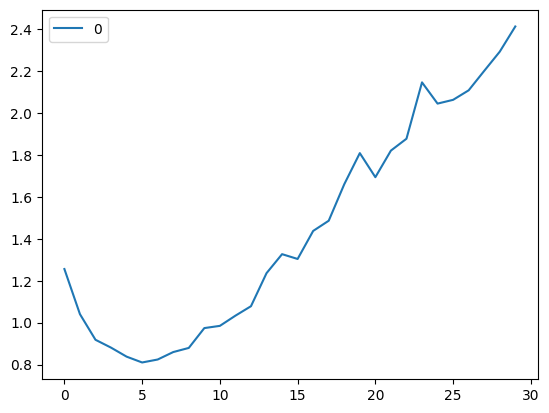

In [38]:
pd.DataFrame(history.history['val_loss']).plot()

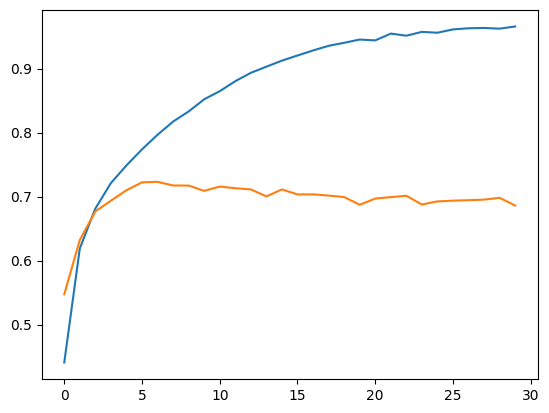

In [41]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

**تعداد پارامترهای یادگیری**

برای لایه اول:



```
Conv2D(32,(2,2))
for each Kernel(2,2) = 2*2=4 Parameters
we have 3 channel for each Filter: 4*3 = 12 for each Filter
we have 1 bios for each filter => 12 + 1 =13
we have 32 Kernels => so for First Layer we have 13 * 32 = 416
```

برای لایه دوم:



```
Conv2D(64,(2,2))
In output last layer we have 32 feature map(channel) equal to number of Kernel in last layer
=> for Second Layer Filters are imposed on each feature map(channel)
=> 2*2 = 4 => each filter
=> 32 feature map(channel) * 4 = 128
=> after product weights and channels we add bios (1 parameter) => 129
=> we have 64 Kernel => 64*129 = 8256
```
برای لایه سوم:



```
Conv2D(128,(2,2))
In output last layer we have 64 feature map(channel) equal to number of Kernel in last layer
=> for Second Layer Filters are imposed on each feature map(channel)
=> 2*2 = 4 => each filter
=> 64 feature map(channel) * 4 = 256
=> after product weights and channels we add bios (1 parameter) => 257
=> we have 64 Kernel => 128*257 = 32896
```
برای لایه چهارم:



```
Flatten()
=> Just the output Maxpull change to a array
output Maxpull => (8,8,128) = Flatten => 8*8*128 = 8192
```
برای لایه پنجم:



```
Dense(32, activation='relu')
=> A role: each Out Neuron in output must be joint to all 8192 input + 1 Bios
=> 8192 + 1 = 8193
=> we have 32 output Neuron => 8193 * 32 = 262176
```
برای لایه ششم:



```
Dense(num_class, activation='relu')
=> A role: each Out Neuron in output must be joint to all 32 input + 1 Bios
=> 32 + 1 = 33
=> we have 32 output Neuron => 33 * 10 = 330
```
در کل:



```
 330 + 262176 + 32896 + 8256 + 416 = 304074
```
------------------------
**بایاس چیست؟**

بایاس مثل جمله ثابت در معادله خط است

(همان b در y = ax + b)



```
خروجی = activation( (w1×x1 + w2×x2 + ... + wn×xn) + b )
                                                    ↑
                                                   bias
```

تشبیه ساده:

فرض کنید می‌خواهید تصمیم بگیرید به مهمانی بروید یا نه:

    وزن‌ها (weights): اهمیت هر عامل (مثلاً باران چقدر مهم است؟)

    بایاس (bias): تمایل کلی شما به مهمانی رفتن

اگر

 bias

 بزرگ باشد، حتی با شرایط بد هم ممکن است بروید!

 نقش بایاس:

 1) انعطاف‌پذیری مدل

 2)فعال کردن نورون با ورودی صفر

 -------------------------
 what is model.complie():


 سوال بسیار خوبی پرسیدید! `model.compile()` مثل **تنظیم موتور ماشین** قبل از شروع مسابقه است.

## model.compile() چه کاری انجام می‌دهد؟

مدل را برای **آموزش (training)** آماده می‌کند. شما سه چیز مهم را به آن می‌گویید:

1. **بهینه‌ساز (Optimizer)** - چطور وزن‌ها را تنظیم کند
2. **تابع ضرر (Loss Function)** - چطور اشتباهات را اندازه بگیرد
3. **معیارها (Metrics)** - چطور عملکرد را ارزیابی کند

## مثال واقعی برای CIFAR-10:

```python
model.compile(
    optimizer='adam',           # بهینه‌ساز
    loss='sparse_categorical_crossentropy',  # تابع ضرر
    metrics=['accuracy']        # معیار ارزیابی
)
```

## توضیح هر بخش:

### 1. **Optimizer (بهینه‌ساز)** - مثل فرمان ماشین
وظیفه تنظیم وزن‌ها برای کاهش خطا را دارد.
```python
optimizer='adam'     # محبوب‌ترین گزینه - سریع و خوب
optimizer='sgd'      # ساده اما کندتر
optimizer='rmsprop'  # گزینه دیگر
```

### 2. **Loss Function (تابع ضرر)** - مثل خطکش برای اندازه‌گیری اشتباهات
می‌گوید "چقدر بد پیش‌بینی کردی؟"
```python
# برای CIFAR-10 (چند کلاس - 10 کلاس):
loss='sparse_categorical_crossentropy'  
# اگر labels شما 0,1,2,...,9 باشند

# یا اگر one-hot encoded باشد:
loss='categorical_crossentropy'

# برای مسائل دودویی (مثل گربه/سگ):
loss='binary_crossentropy'

# برای پیش‌بینی عدد (مثل قیمت خانه):
loss='mse'  # mean squared error
```

### 3. **Metrics (معیارها)** - مثل نمره‌دهی به مدل
برای ارزیابی عملکرد در حین آموزش.
```python
metrics=['accuracy']           # دقت - چندتا درست جواب داد
metrics=['accuracy', 'mse']    # چندتا معیار همزمان
```

## تفاوت Loss و Metrics:
- **Loss**: برای آموزش و به‌روزرسانی وزن‌ها استفاده می‌شود
- **Metrics**: فقط برای نمایش و ارزیابی - در آموزش تأثیری ندارد

```
## تشبیه ساده:
- **model = ساخت ماشین** (لایه‌ها را اضافه می‌کنید)
- **model.compile = تنظیم موتور** (چطور کار کند)
- **model.fit = راندن ماشین** (آموزش واقعی)
```

--------------------------------------
**what is Epoch, Batch_Size?**

<div dir="rtl">
فرض میکنیم 500000 عدد داده اموزشی داریم. برای شروع اموزش Epoch  را برابر 30 درنظر میگیرم. همچنین پارامتر batch_size  را برابر با 64 در نظر می گیریم.
وقتی میگوییم یک epoch ینی اینکه کل داده ها برای یک که شده وارد مدل شود. حال با توجه به انیکه پارامتر batch_size   در اینجا برابر 64 هست کل داده ها به 782 دسته تقسیم میشود. و هر epoch من 782 دسته خواهیم داشت. حالا فرض کن در epoch=1 و batch=1 64 عدد تصویر وجود دارد و به حفظ پارامتر ها این تصاویر وارد مدل شده و دونه به دونه پردازش می شود. پس در هس batch من 64 تا Loss خواهم داشت که میانگین ان گرفته می شود و بر اساس ان یکبار پارمتر ها به روز رسانی میشود. خالا میره برای دسته بعدی تا برسه به دسته 782 تا یک epoch کامل گذارنده شود. حال به خط زیر توجه کنیم:
</div>



```
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4407 - loss: 1.5391 - val_accuracy: 0.5473 - val_loss: 1.2560
```

<div dir="rtl">
در اینجا 782 تا loss داریم که میانگین آن نشان داده میشود. برای بقیه معیار ها هم به این صورت در نظر گرفته می شود.
حال با توجه به تعداد مقادیری که برای batch_size در نظر میگیریم، سه حالت در نظر گرفته می شود:

حالت 1) batch_size=64  (Mini-Batch Gradient Decent)
در این جا به تعداد 782 * 30 بار مرتبه به روزرسانی رخ می دهد. در این روش یک تعادل بین میران درگیری GPU و RAM ایجاد میگردد تا به طور کامل کل منابع درگیر نشود.


حالت 2) batch_size=500000 کل داده ها (Batch Gradient Decent)
یعنی یک بار کل داده به مدل داده میشه و 500000 هزار loss بدست میاد و از ان میانگین گرفته می شود. و بر اساس ان میانگین به روزرسانی انجام می شود. در اینجا تنها 30 بار به روزرسانی داده صورت میگیرد.
در این روش حافظه بسیار درگیر می شود و بسیار پر هزینه است. اما دقیق است.


حالت 3) batch_size=1  (Stochastic Gradient Decent)
در این حالت برای هر تصویر به روزرسانی داده انچام میشود. در واقع در این جا طول هر دسته یکی است. این روش به دلیل نویری بودن ناپایداری زیادی خواهد داشت و دقت ان بسیار کم خواهد بود. و خیلی دیر به همگرایی می رسد.

</div>

-----------------------

<div dir='rtl'>

**بررسی accurecy--loss--val_accuracy--val_loss**:

به ستون accuracy نگاه کنید:

    Epoch 1: 44%

    Epoch 10: 85%

    Epoch 20: 94%

    Epoch 30: 96%

یعنی مدل دارد یاد می‌گیرد! هر epoch دقت روی داده آموزشی بالاتر می‌رود.

به ستون val_accuracy دقت کنید:

    Epoch 1: 54.7%

    Epoch 5: 70.9%

    Epoch 10: 70.8%

    Epoch 20: 68.7%

    Epoch 30: 68.5%

چه اتفاقی افتاده؟

    تا Epoch 5، دقت تست بالا رفته

    بعد از آن، دیگر بالا نمی‌رود، حتی کم هم می‌شود!

    اما دقت آموزش همچنان بالا می‌رود (تا 96%)

این یعنی Overfitting: مدل تصاویر آموزشی را حفظ کرده اما تعمیم دادن به تصاویر جدید را بلد نیست.

</div>

--------------------------

<div dir='rtl'>

**Dropout چیست**

Dropout یعنی در هر مرحله از آموزش، تعدادی از نورون‌ها را به طور تصادفی خاموش می‌کنیم.

Dropout چگونه عمل می‌کند؟

در هر batch از آموزش:

    یک ماسک تصادفی ساخته می‌شود (مثل قرعه‌کشی)

    هر نورون با احتمال p (مثلاً 0.5) حذف می‌شود (خروجی = 0)

    نورون‌های باقیمانده مقیاس‌دهی می‌شوند
 مدل وابسته به چند نورون خاص می‌شود (همان 11 بازیکن ثابت)

راه حل Dropout:

    هر بار نورون‌های متفاوتی خاموش می‌شوند

    مدل مجبور می‌شود چندین راه مختلف برای تصمیم‌گیری یاد بگیرد

    نتیجه: تعمیم بهتر روی داده تست

1. Dropout در لایه Conv2D
python

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Dropout(0.25))  # 25% نورون‌های این لایه خاموش می‌شوند

چگونه عمل می‌کند؟

    نورون‌های خاموش شده کل کانال نیستند، بلکه نقاط تصادفی در نقشه ویژگی هستند

    یعنی بعضی از پیکسل‌های خاص در نقشه ویژگی صفر می‌شوند

نکته: معمولاً نرخ Dropout در Conv پایین است (0.1 تا 0.3)
2. Dropout در لایه Flatten
python

model.add(Flatten())
model.add(Dropout(0.5))  # در عمل معمولاً بین Flatten و Dense استفاده می‌شود

چگونه عمل می‌کند؟

    Flatten خودش پارامتری ندارد که Dropout روی آن اثر بگذارد

    Dropout را بعد از Flatten و قبل از Dense می‌گذاریم

    در این حالت روی بردار 8192 تایی اثر می‌گذارد

تأکید: Dropout مستقیماً روی لایه Flatten اعمال نمی‌شود، بلکه روی خروجی آن.
3. Dropout در لایه Dense
python

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # 50% نورون‌های این لایه خاموش می‌شوند

چگونه عمل می‌کند؟

    مستقیماً روی نورون‌های لایه Dense اثر می‌گذارد

    هر نورون به طور مستقل با احتمال 0.5 خاموش می‌شود

نکته: نرخ Dropout در Dense معمولاً بالاست (0.5)

</div>

---------------------


